# 01 — Análise Exploratória de Dados

**Dimensão 3 da rúbrica — 20 pontos.**

Toda visualização precisa de um parágrafo de interpretação logo abaixo.
Gráfico sem leitura perde metade dos pontos do critério.

In [126]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

credit_record = Path("..") / "data" / "raw" / "credit_record.csv" 
application_record = Path("..") / "data" / "raw" / "application_record.csv"

credit_record = pd.read_csv(credit_record)
application_record = pd.read_csv(application_record)

df = pd.merge(credit_record, application_record, on="ID", how="inner")
df.head()
df.to_csv('../data/raw/df.csv', index=False)

RAW = Path("..") / "data" / "raw" / "df.csv"          # PREENCHER: nome do arquivo
PROCESSED = Path("..") / "data" / "processed"
TARGET = "STATUS"                                            # PREENCHER: variável alvo

pd.set_option("display.max_columns", None)

In [127]:
df = pd.read_csv(RAW)
df.head()

,ID,MONTHS_BALANCE,STATUS,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,0,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008804,-1,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008804,-2,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
3,5008804,-3,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
4,5008804,-4,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0


## 1. Visão geral

_Dimensões, tipos e primeira impressão do dataset._

In [128]:
df.shape

(777715, 20)

In [129]:
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 777715 entries, 0 to 777714
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   777715 non-null  int64  
 1   MONTHS_BALANCE       777715 non-null  int64  
 2   STATUS               777715 non-null  str    
 3   CODE_GENDER          777715 non-null  str    
 4   FLAG_OWN_CAR         777715 non-null  str    
 5   FLAG_OWN_REALTY      777715 non-null  str    
 6   CNT_CHILDREN         777715 non-null  int64  
 7   AMT_INCOME_TOTAL     777715 non-null  float64
 8   NAME_INCOME_TYPE     777715 non-null  str    
 9   NAME_EDUCATION_TYPE  777715 non-null  str    
 10  NAME_FAMILY_STATUS   777715 non-null  str    
 11  NAME_HOUSING_TYPE    777715 non-null  str    
 12  DAYS_BIRTH           777715 non-null  int64  
 13  DAYS_EMPLOYED        777715 non-null  int64  
 14  FLAG_MOBIL           777715 non-null  int64  
 15  FLAG_WORK_PHONE      777715 

,count,mean,std,min,25%,50%,75%,max
ID,777715.0,5.078743e+06,41804.424817,5008804.0,5044568.5,5069530.0,5115551.0,5150487.0
MONTHS_BALANCE,777715.0,-1.937356e+01,14.082208,-60.0,-29.0,-17.0,-8.0,0.0
CNT_CHILDREN,777715.0,4.280823e-01,0.745755,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,777715.0,1.885348e+05,101622.450077,27000.0,121500.0,162000.0,225000.0,1575000.0
DAYS_BIRTH,777715.0,-1.612494e+04,4104.304018,-25152.0,-19453.0,-15760.0,-12716.0,-7489.0
DAYS_EMPLOYED,777715.0,5.777583e+04,136471.735391,-15713.0,-3292.0,-1682.0,-431.0,365243.0
FLAG_MOBIL,777715.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,777715.0,2.318176e-01,0.421993,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,777715.0,3.009650e-01,0.458678,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,777715.0,9.167497e-02,0.288567,0.0,0.0,0.0,0.0,1.0


**Interpretação**

Há valores nulos na coluna OCCUPATION_TYPE.

Na coluna CNT_CHILDREN há um range de 0 a 19 filhos. Verificar se há outlier e se está influenciando na coluna CNT_FAM_MEMBERS.

In [130]:
# Verificando os valores únicos de cada coluna
for col in df.columns:
    print(f"Coluna: {col}, Valores únicos: {df[col].nunique()}")

Coluna: ID, Valores únicos: 36457
Coluna: MONTHS_BALANCE, Valores únicos: 61
Coluna: STATUS, Valores únicos: 8
Coluna: CODE_GENDER, Valores únicos: 2
Coluna: FLAG_OWN_CAR, Valores únicos: 2
Coluna: FLAG_OWN_REALTY, Valores únicos: 2
Coluna: CNT_CHILDREN, Valores únicos: 9
Coluna: AMT_INCOME_TOTAL, Valores únicos: 265
Coluna: NAME_INCOME_TYPE, Valores únicos: 5
Coluna: NAME_EDUCATION_TYPE, Valores únicos: 5
Coluna: NAME_FAMILY_STATUS, Valores únicos: 5
Coluna: NAME_HOUSING_TYPE, Valores únicos: 6
Coluna: DAYS_BIRTH, Valores únicos: 7183
Coluna: DAYS_EMPLOYED, Valores únicos: 3640
Coluna: FLAG_MOBIL, Valores únicos: 1
Coluna: FLAG_WORK_PHONE, Valores únicos: 2
Coluna: FLAG_PHONE, Valores únicos: 2
Coluna: FLAG_EMAIL, Valores únicos: 2
Coluna: OCCUPATION_TYPE, Valores únicos: 18
Coluna: CNT_FAM_MEMBERS, Valores únicos: 10


**Interpretação**

A coluna FLAG_MOBIL contém apenas um valor para todas as linhas.
Colunas CODE_GENDER, FLAG_OWN_CAR, FLAG_OWN_REALTY, FLAG_WORK_PHONE, FLAG_PHONE e FLAG_EMAIL contém valores booleanos.

In [131]:
# Confirmando se os valores únicos das colunas são booleanas
print(f'CODE_GENDER: {df.CODE_GENDER.unique()} \n')
print(f'FLAG_OWN_CAR: {df.FLAG_OWN_CAR.unique()} \n')
print(f'FLAG_OWN_REALTY: {df.FLAG_OWN_REALTY.unique()} \n')
print(f'FLAG_WORK_PHONE: {df.FLAG_WORK_PHONE.unique()} \n')
print(f'FLAG_PHONE: {df.FLAG_PHONE.unique()} \n')
print(f'FLAG_EMAIL: {df.FLAG_EMAIL.unique()} \n')

CODE_GENDER: <StringArray>
['M', 'F']
Length: 2, dtype: str 

FLAG_OWN_CAR: <StringArray>
['Y', 'N']
Length: 2, dtype: str 

FLAG_OWN_REALTY: <StringArray>
['Y', 'N']
Length: 2, dtype: str 

FLAG_WORK_PHONE: [1 0] 

FLAG_PHONE: [0 1] 

FLAG_EMAIL: [0 1] 



In [132]:
# Vericando valores da coluna OCCUPATION_TYPE
df['OCCUPATION_TYPE'].value_counts()

OCCUPATION_TYPE
Laborers                 131572
Core staff                77112
Sales staff               70362
Managers                  67738
Drivers                   47678
High skill tech staff     31768
Accountants               27223
Medicine staff            26691
Cooking staff             13416
Security staff            12400
Cleaning staff            11399
Private service staff      6714
Low-skill Laborers         3623
Secretaries                3149
Waiters/barmen staff       2557
HR staff                   1686
IT staff                   1319
Realty agents              1260
Name: count, dtype: int64

**Interpretação**

Nota-se que os valores não nulos se referem à cargos dos candidatos contratados.

Hipótese: valores nulos são de candidatos não contratados.

In [133]:
# Verificando valores duplicados
df.duplicated().sum()

np.int64(0)

**Interpretação**

Não há valores duplicados.

## 2. Distribuição das variáveis

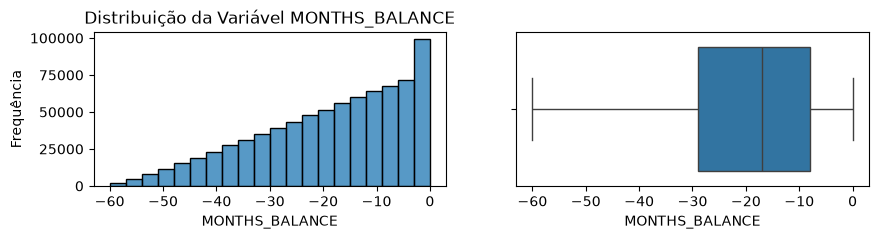

In [134]:
# Plotando distribuição e boxplot da coluna MONTHS_BALANCE

fig, axes = plt.subplots(1, 2, figsize=(10, 2))

sns.histplot(data=df.MONTHS_BALANCE, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável MONTHS_BALANCE')
axes[0].set_xlabel('MONTHS_BALANCE')
axes[0].set_ylabel('Frequência')

sns.boxplot(x='MONTHS_BALANCE', data=df, ax=axes[1]) 

plt.show()

**Interpretação:**

Mostra que há mais valores coletados quanto mais recente é o mês e não apresenta outliers.

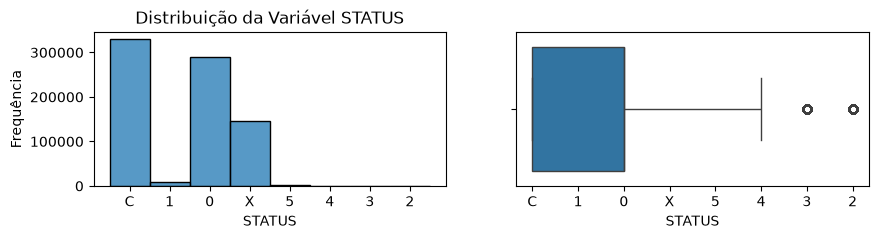

In [135]:
# Plotando distribuição e boxplot da variável alvo

fig, axes = plt.subplots(1, 2, figsize=(10, 2))

sns.histplot(data=df.STATUS, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável STATUS')
axes[0].set_xlabel('STATUS')
axes[0].set_ylabel('Frequência')

sns.boxplot(x=TARGET, data=df, ax=axes[1])    

plt.show()

0: 1-29 dias vencidos

1: 30-59 dias vencidos

2: 60-89 dias vencidos

3: 90-119 dias vencidos

4: 120-149 dias vencidos

5: Dívidas vencidas ou vencidas, baixas por mais de 150 dias

C: liquidadas naquele mês

X: Nenhum empréstimo para o mês

**Interpretação**

A maior parte dos dados está no primeiro quartil.
Há outliers, porém são valores que não podem ser ignorados, pois são dados de operações vencidas.

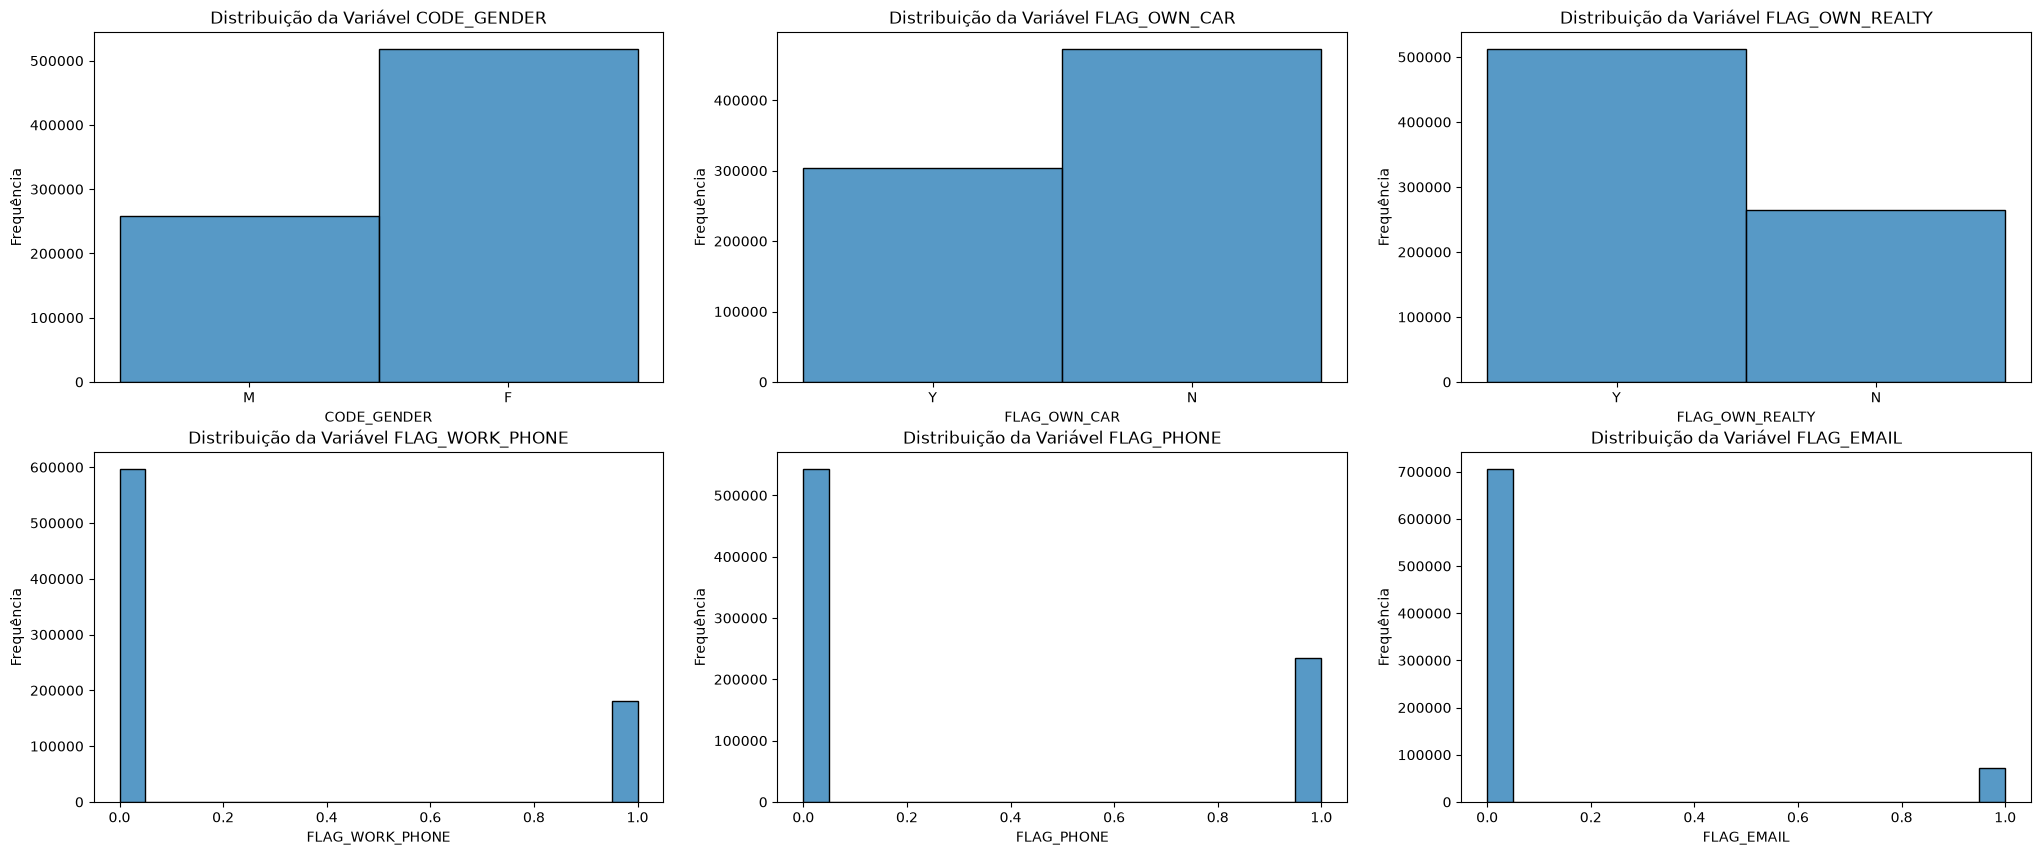

In [136]:
# Plotando distribuição para variáveis booleanas (CODE_GENDER, FLAG_OWN_CAR, FLAG_OWN_REALTY, FLAG_WORK_PHONE,, 
# FLAG_PHONE, FLAG_EMAIL, DAYS_EMPLOYED )

fig, axes = plt.subplots(2, 3, figsize=(25, 10))

sns.histplot(data=df.CODE_GENDER, bins=20, ax=axes[0][0])
axes[0][0].set_title('Distribuição da Variável CODE_GENDER')
axes[0][0].set_xlabel('CODE_GENDER')
axes[0][0].set_ylabel('Frequência')

sns.histplot(data=df.FLAG_OWN_CAR, bins=20, ax=axes[0][1])
axes[0][1].set_title('Distribuição da Variável FLAG_OWN_CAR')
axes[0][1].set_xlabel('FLAG_OWN_CAR')
axes[0][1].set_ylabel('Frequência') 

sns.histplot(data=df.FLAG_OWN_REALTY, bins=20, ax=axes[0][2])
axes[0][2].set_title('Distribuição da Variável FLAG_OWN_REALTY')
axes[0][2].set_xlabel('FLAG_OWN_REALTY')
axes[0][2].set_ylabel('Frequência')

sns.histplot(data=df.FLAG_WORK_PHONE, bins=20, ax=axes[1][0])
axes[1][0].set_title('Distribuição da Variável FLAG_WORK_PHONE') 
axes[1][0].set_xlabel('FLAG_WORK_PHONE')
axes[1][0].set_ylabel('Frequência')

sns.histplot(data=df.FLAG_PHONE, bins=20, ax=axes[1][1])
axes[1][1].set_title('Distribuição da Variável FLAG_PHONE')
axes[1][1].set_xlabel('FLAG_PHONE')
axes[1][1].set_ylabel('Frequência')

sns.histplot(data=df.FLAG_EMAIL, bins=20, ax=axes[1][2])
axes[1][2].set_title('Distribuição da Variável FLAG_EMAIL')
axes[1][2].set_xlabel('FLAG_EMAIL')
axes[1][2].set_ylabel('Frequência')

plt.show()

**Interpretação**

Todos os gráficos mostraram que há mais dados em um grupo do que para outro.

Há mais candidatas do que candidatos.

Há mais candidatos sem carro do que com.

Há mais candidatos com propriedade do que sem.

Há mais candidatos que não usam celular para trabalho do que os que usam.

Há mais candidatos sem telefone do que com.

Há mais candidatos sem e-mail do que com.

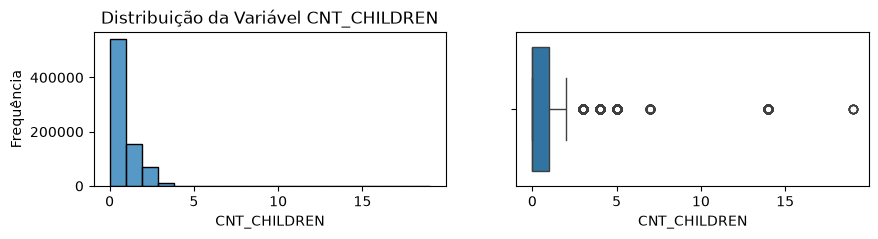

In [137]:
# Plotando distribuição e boxplot da coluna CNT_CHILDREN

fig, axes = plt.subplots(1, 2, figsize=(10, 2))

sns.histplot(data=df.CNT_CHILDREN, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável CNT_CHILDREN')
axes[0].set_xlabel('CNT_CHILDREN')
axes[0].set_ylabel('Frequência')

sns.boxplot(x='CNT_CHILDREN', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Gráfico mostra assimetria à direita, com mais dados localizados na parte esquerda do gráfico.
Há outliers, porém não se sabe ainda se pode descartá-los ou não.

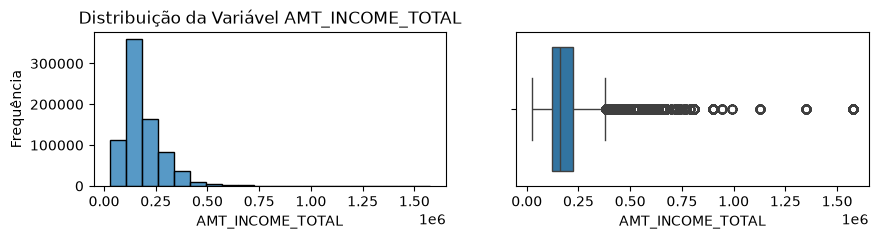

In [138]:
# Plotando distribuição e boxplot da coluna AMT_INCOME_TOTAL

fig, axes = plt.subplots(1, 2, figsize=(10, 2))

sns.histplot(data=df.AMT_INCOME_TOTAL, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável AMT_INCOME_TOTAL')
axes[0].set_xlabel('AMT_INCOME_TOTAL')
axes[0].set_ylabel('Frequência')

sns.boxplot(x='AMT_INCOME_TOTAL', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Gráfico mostra assimetria à direita, com mais dados localizados na parte esquerda do gráfico.
Há outliers, porém não se sabe ainda se pode descartá-los ou não.

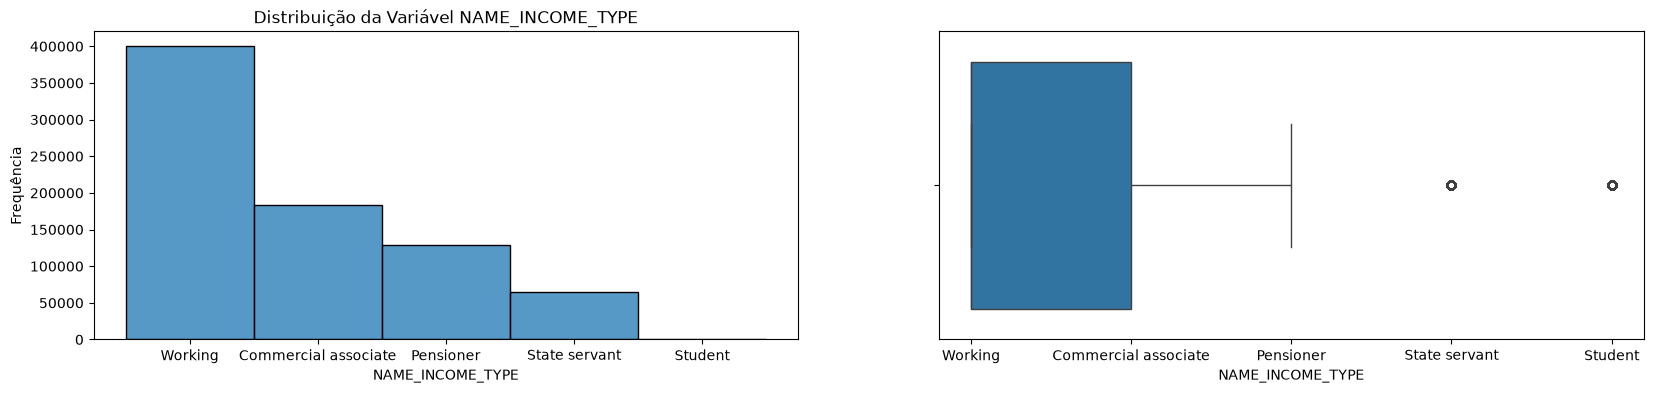

In [139]:
# Plotando distribuição e boxplot da coluna NAME_INCOME_TYPE

fig, axes = plt.subplots(1, 2, figsize=(20, 4))

sns.histplot(data=df.NAME_INCOME_TYPE, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável NAME_INCOME_TYPE')
axes[0].set_xlabel('NAME_INCOME_TYPE')
axes[0].set_ylabel('Frequência')

sns.boxplot(x='NAME_INCOME_TYPE', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Gráfico mostra assimetria à direita, com mais dados localizados na parte esquerda do gráfico.
Há outliers, porém não se sabe ainda se pode descartá-los ou não.

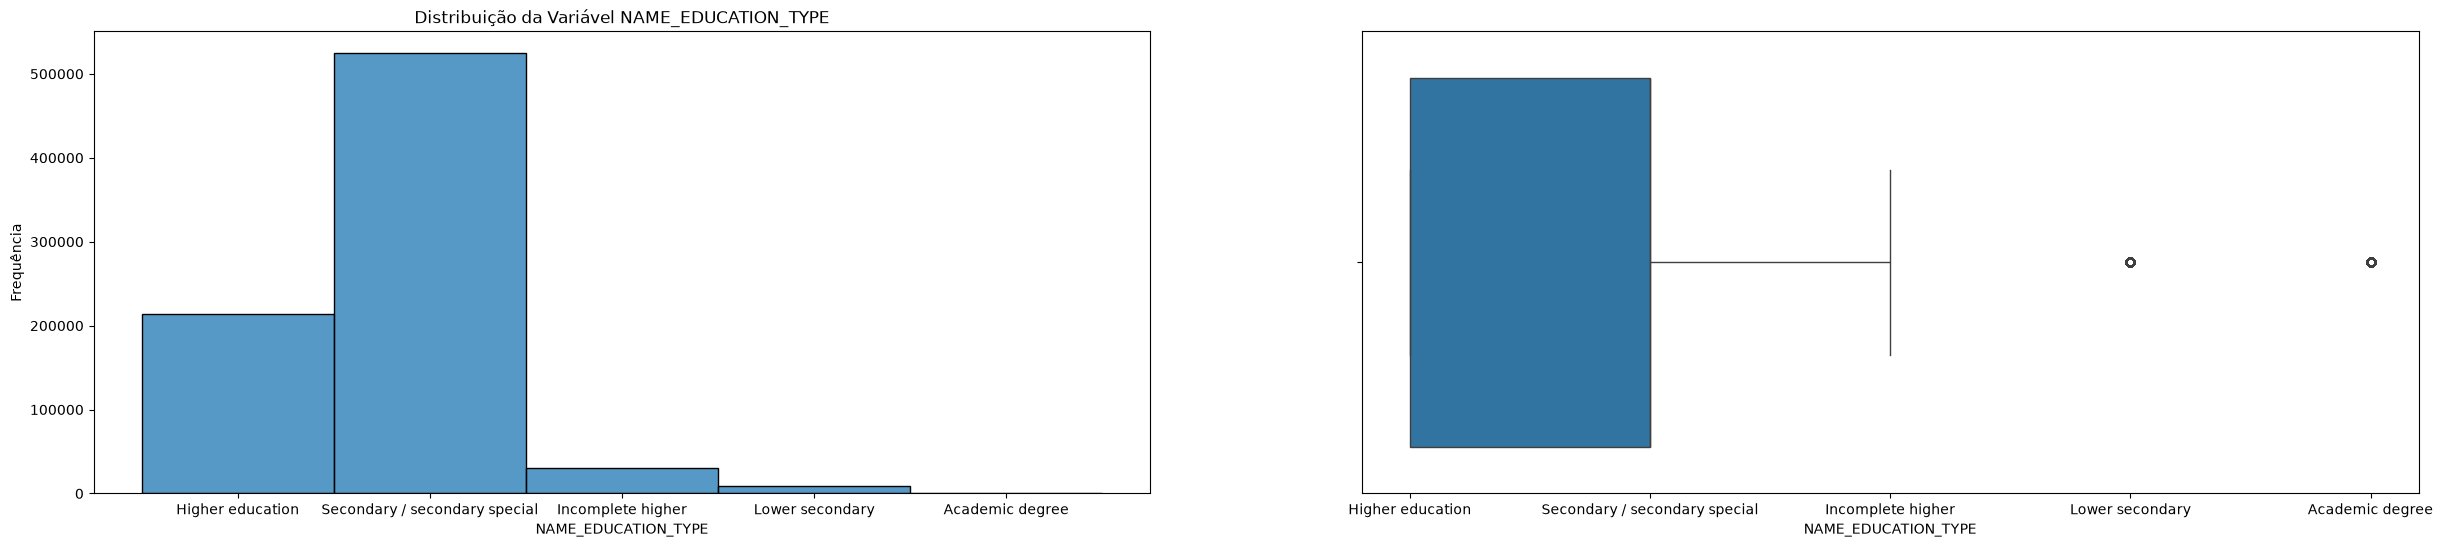

In [140]:
# Plotando distribuição e boxplot da coluna NAME_EDUCATION_TYPE

fig, axes = plt.subplots(1, 2, figsize=(30, 6))

sns.histplot(data=df.NAME_EDUCATION_TYPE, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável NAME_EDUCATION_TYPE')
axes[0].set_xlabel('NAME_EDUCATION_TYPE')
axes[0].set_ylabel('Frequência')

sns.boxplot(x='NAME_EDUCATION_TYPE', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Gráfico mostra assimetria à direita, com mais dados localizados na parte esquerda do gráfico.
Há outliers, porém não se sabe ainda se pode descartá-los ou não.

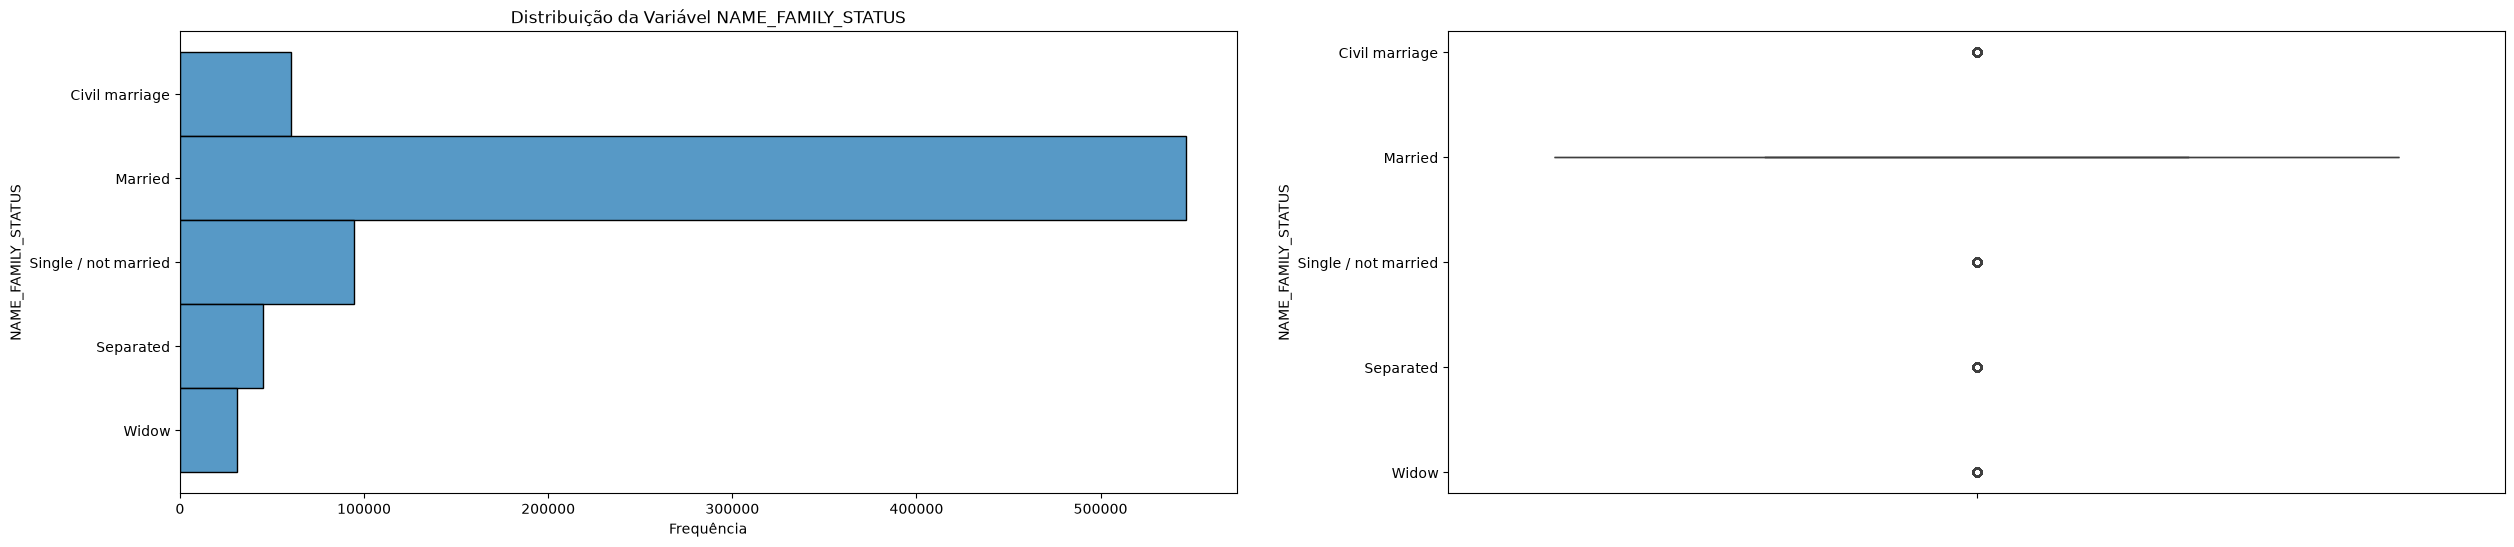

In [141]:
# Plotando distribuição e boxplot da coluna NAME_FAMILY_STATUS

fig, axes = plt.subplots(1, 2, figsize=(30, 6))

sns.histplot(y=df.NAME_FAMILY_STATUS, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável NAME_FAMILY_STATUS')
axes[0].set_ylabel('NAME_FAMILY_STATUS')
axes[0].set_xlabel('Frequência')

sns.boxplot(y='NAME_FAMILY_STATUS', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Maior parte dos candidatos são casados.

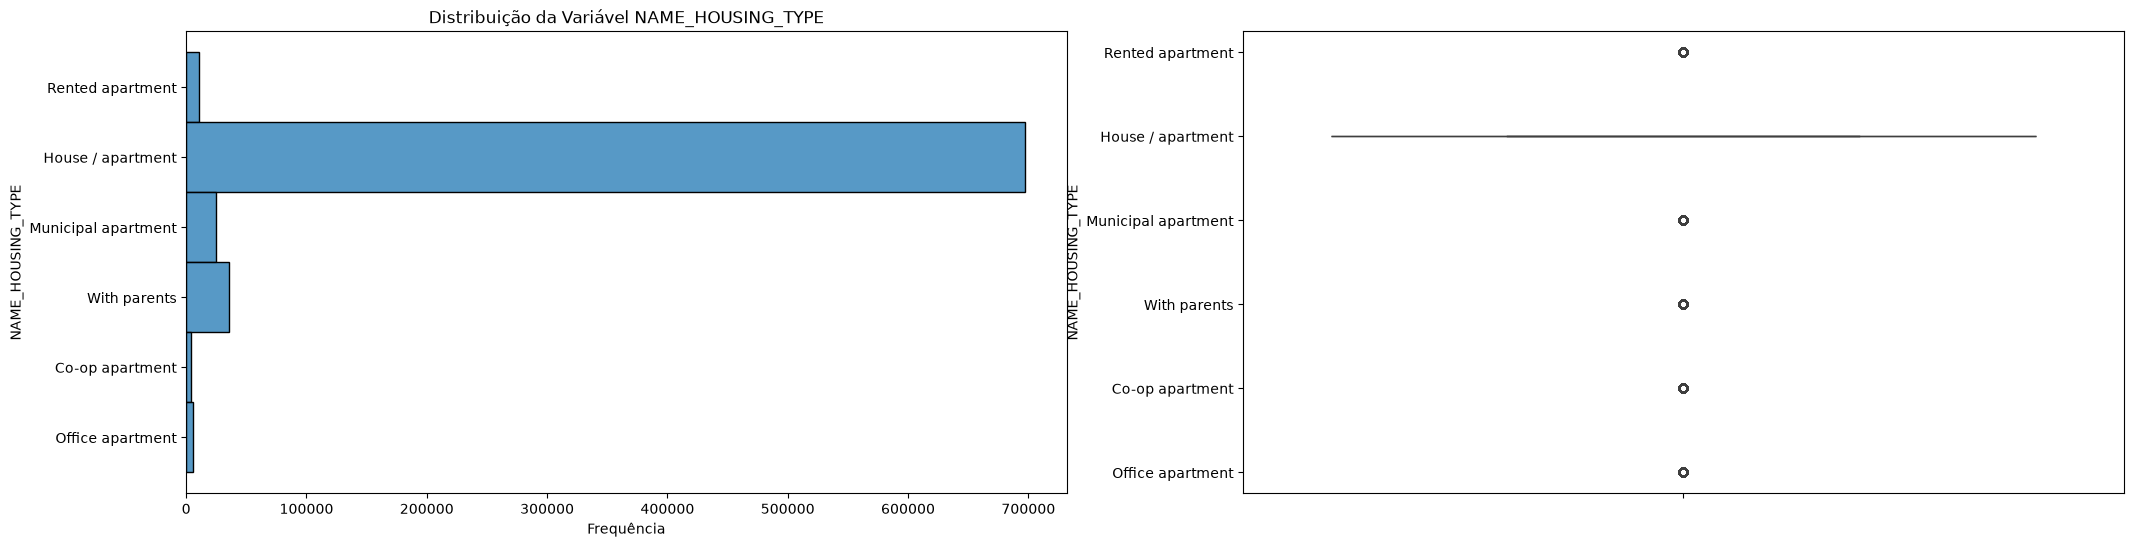

In [142]:
# Plotando distribuição e boxplot da coluna NAME_HOUSING_TYPE

fig, axes = plt.subplots(1, 2, figsize=(25, 6))

sns.histplot(y=df.NAME_HOUSING_TYPE, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável NAME_HOUSING_TYPE')
axes[0].set_ylabel('NAME_HOUSING_TYPE')
axes[0].set_xlabel('Frequência')

sns.boxplot(y='NAME_HOUSING_TYPE', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Maior parte dos candidatos possuem casa ou apartamento.

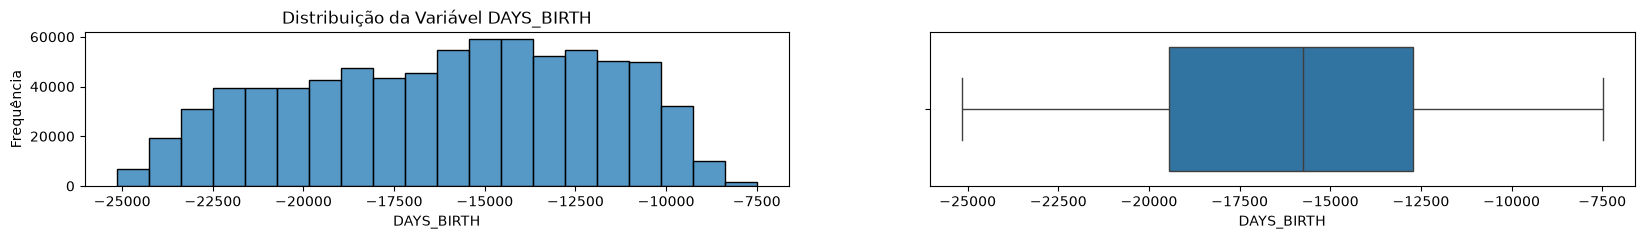

In [143]:
# Plotando distribuição e boxplot da coluna DAYS_BIRTH

fig, axes = plt.subplots(1, 2, figsize=(20, 2))

sns.histplot(data=df.DAYS_BIRTH, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável DAYS_BIRTH')
axes[0].set_xlabel('DAYS_BIRTH')
axes[0].set_ylabel('Frequência')

sns.boxplot(x='DAYS_BIRTH', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Não há outliers.
Dados bem distribuídos

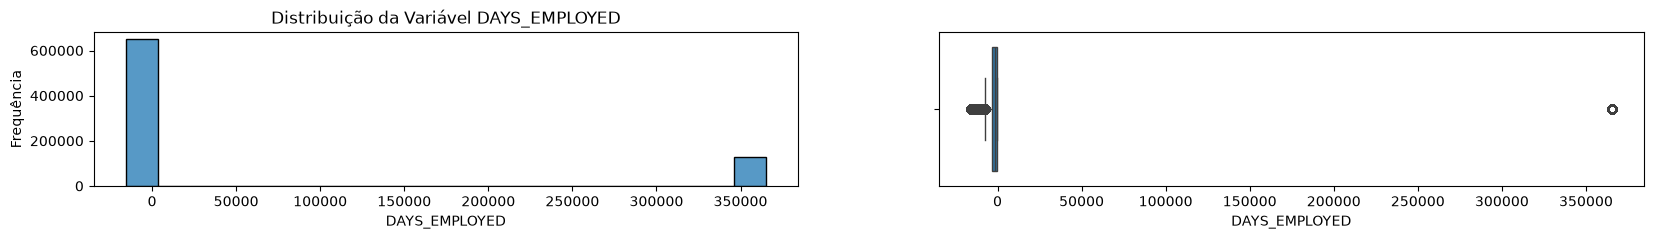

In [144]:
# Plotando distribuição e boxplot da coluna DAYS_EMPLOYED

fig, axes = plt.subplots(1, 2, figsize=(20, 2))

sns.histplot(data=df.DAYS_EMPLOYED, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável DAYS_EMPLOYED')
axes[0].set_xlabel('DAYS_EMPLOYED')
axes[0].set_ylabel('Frequência')

sns.boxplot(x='DAYS_EMPLOYED', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Há dados bem extremos

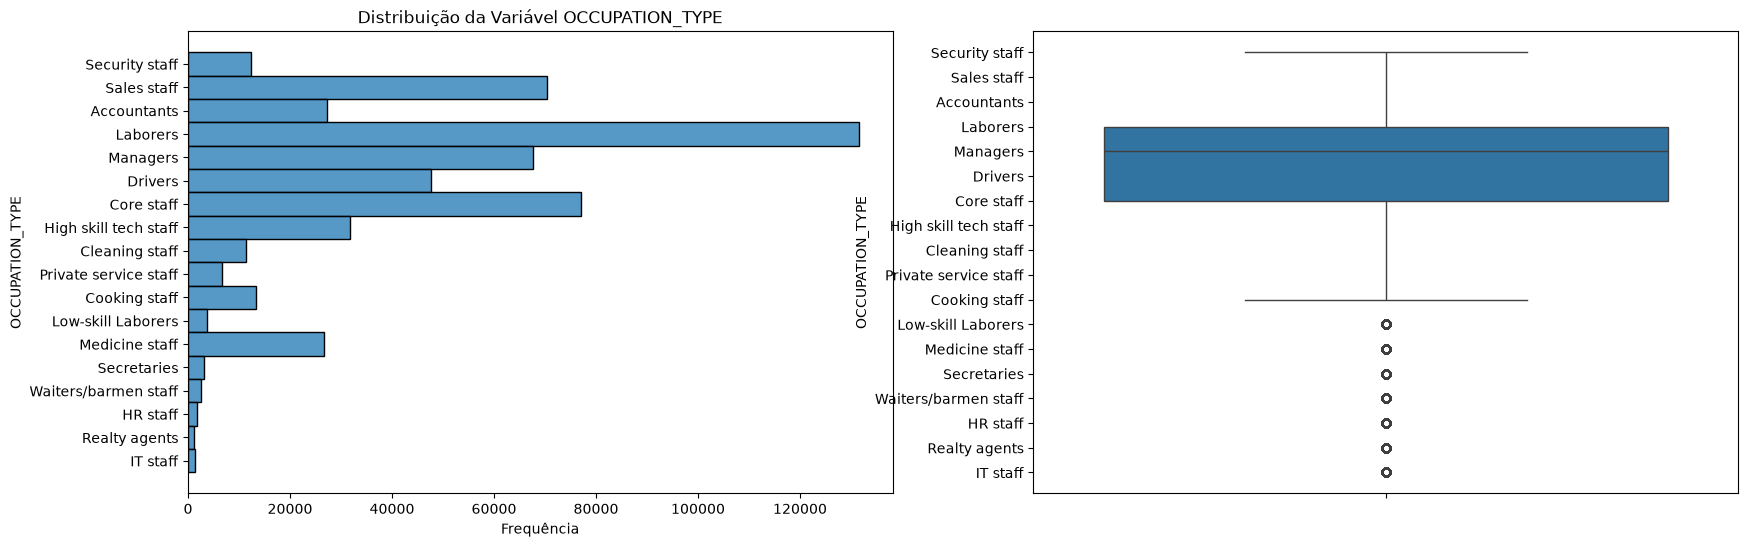

In [145]:
# Plotando distribuição e boxplot da coluna OCCUPATION_TYPE

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.histplot(y=df.OCCUPATION_TYPE, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável OCCUPATION_TYPE')
axes[0].set_ylabel('OCCUPATION_TYPE')
axes[0].set_xlabel('Frequência')

sns.boxplot(y='OCCUPATION_TYPE', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Há outliers, mas não se sabe ainda se podemos exluí-los

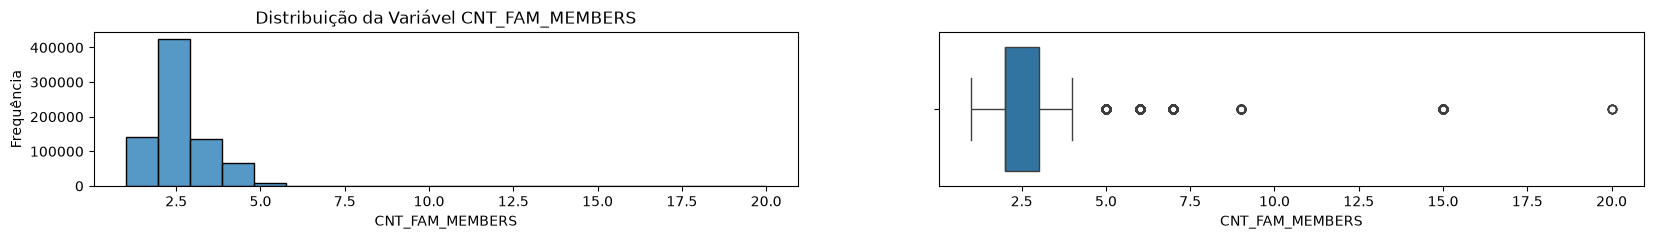

In [146]:
# Plotando distribuição e boxplot da coluna CNT_FAM_MEMBERS

fig, axes = plt.subplots(1, 2, figsize=(20, 2))

sns.histplot(data=df.CNT_FAM_MEMBERS, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável CNT_FAM_MEMBERS')
axes[0].set_xlabel('CNT_FAM_MEMBERS')
axes[0].set_ylabel('Frequência')

sns.boxplot(x='CNT_FAM_MEMBERS', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Gráfico mostra assimetria à direita, com mais dados localizados na parte esquerda do gráfico.
Há outliers, porém não se sabe ainda se pode descartá-los ou não.

## 3. Correlações

**Interpretação:** _comente cada correlação relevante, uma a uma._

In [147]:
# Retirando a coluna FLAG_MOBIL, pois todos os valores são iguais a 1, o que não contribui para a análise de correlação.
df = df.drop(columns=['FLAG_MOBIL'])

# Retirando a coluna ID, pois todos os valores são diferentes, o que não contribui para a análise de correlação.
df = df.drop(columns=['ID'])

In [148]:
# Tratando a coluna STATUS, transformando os valores C e X em 5 e 6
df['STATUS'] = df['STATUS'].apply(lambda x: 5 if x == 'C' else 6 if x == 'X' else x)
df.STATUS.unique()

array([5, '1', '0', 6, '5', '4', '3', '2'], dtype=object)

In [149]:
# Mudando o tipo da coluna STATUS para inteiro
df['STATUS'] = df['STATUS'].astype('int64')

<Axes: >

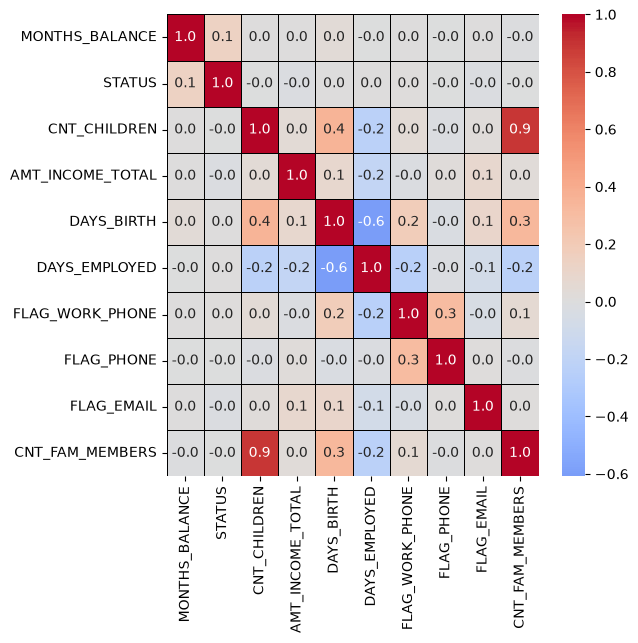

In [150]:
# Plotando a matriz de correlação das variáveis numéricas

plt.figure(figsize=(6, 6))
matriz_corr = df.corr(numeric_only=True)
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".1f", center=0, linewidths=0.5, linecolor='black')

**Interpretação**

--------------

Colunas com 40% de correlação:

CNT_FAM_MEMBERS e CNT_CHILDREN

Tem forte correlação, uma vez que uma depende da outra.

--------------

Colunas com 40% de correlação:

CNT_CHILDREN e DAYS_BIRTH

--------------

Colunas com 30% de correlação:

CNT_FAM_MEMBERS e DAYS_BIRTH



## 4. Outliers

**Interpretação:** _remover, winsorizar ou manter? Justifique._

In [151]:
# Detecção de outliers usando o método do IQR (Interquartile Range) para as colunas numéricas:

for col in df.select_dtypes(include=['float64', 'int64']).columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  if not outliers.empty:
    print(f"Coluna: {col}, Outliers: {len(outliers)}")

Coluna: CNT_CHILDREN, Outliers: 11039
Coluna: AMT_INCOME_TOTAL, Outliers: 33987
Coluna: DAYS_EMPLOYED, Outliers: 163348
Coluna: FLAG_WORK_PHONE, Outliers: 180288
Coluna: FLAG_EMAIL, Outliers: 71297
Coluna: CNT_FAM_MEMBERS, Outliers: 10631


Analisando cada coluna

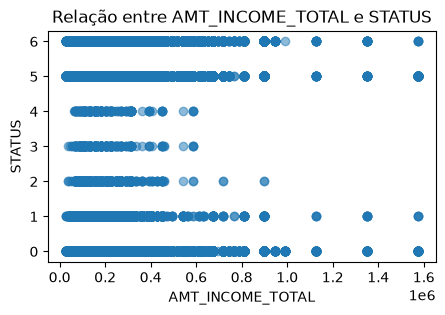

In [152]:
# AMT_INCOME_TOTAL

# Plotando um gráfico de dispersão para a variável AMT_INCOME_TOTAL em relação à variável alvo STATUS
plt.figure(figsize=(5, 3))
plt.scatter(x=df.AMT_INCOME_TOTAL, y=df.STATUS, alpha=0.5)
plt.title('Relação entre AMT_INCOME_TOTAL e STATUS')
plt.xlabel('AMT_INCOME_TOTAL')
plt.ylabel('STATUS')
plt.show()


In [153]:
# CNT_CHILDREN
df.CNT_CHILDREN.unique()




array([ 0,  1,  3,  2,  4,  5, 14, 19,  7])

## 5. Balanceamento de classes

**Interpretação:** _qual a proporção entre as classes e o que isso implica na escolha das métricas?_

In [154]:
#df[TARGET].value_counts(normalize=True)

## 6. Síntese da EDA

_Amarre os achados em uma narrativa única — é ela que vira o storytelling da apresentação._